In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import plot_points, plot_decision_boundary

### TASK 1

In [2]:
NAND_data = np.array([[0,0,1],[0,1,1],[1,0,1],[1,1,0]])
NOR_data = np.array([[0,0,1],[1,0,0],[0,1,0],[1,1,0]])

### TASK 2

In [3]:
XOR_data = np.array([[0,0,0],[0,1,1],[1,0,1],[1,1,0]])
XNOR_data = np.array([[0,0,1],[1,0,0],[0,1,0],[1,1,1]])

In [4]:
NAND_plot_data = NAND_data.copy()
NOR_plot_data = NOR_data.copy()
XNOR_plot_data = XNOR_data.copy()
XOR_plot_data = XOR_data.copy()

### TASK 3

In [5]:
array_minus_1 = np.array([[-1],[-1],[-1],[-1]])
NAND_data = np.hstack((array_minus_1,NAND_data))
NOR_data = np.hstack((array_minus_1,NOR_data))
XOR_data = np.hstack((array_minus_1,XOR_data))
XNOR_data = np.hstack((array_minus_1,XNOR_data))

In [6]:
for i in range(NAND_data.shape[0]):
    if NAND_data[i,-1] == 0:
        NAND_data[i] = -NAND_data[i]
    if NOR_data[i,-1] == 0:
        NOR_data[i] = -NOR_data[i]
    if XOR_data[i,-1] == 0:
        XOR_data[i] = -XOR_data[i]
    if XNOR_data[i,-1] == 0:
        XNOR_data[i] = -XNOR_data[i]

In [7]:
algo_NAND_data = NAND_data[:,:-1]
algo_NOR_data = NOR_data[:,:-1]
algo_XOR_data = XOR_data[:,:-1]
algo_XNOR_data = XNOR_data[:,:-1]

In [8]:
algo_NAND_data

array([[-1,  0,  0],
       [-1,  0,  1],
       [-1,  1,  0],
       [ 1, -1, -1]])

### TASK 4

In [9]:
def check (algo_data,w):
    for row in algo_data:
        res=np.dot(row,w)
        if res<= 0:
            return False,row

    return True,np.empty((1,3))
        

In [10]:
w_NAND = np.array([0,0,0])
while True:
    possible,v_fail=check(algo_NAND_data,w_NAND)
    if possible:
        break
    w_NAND=w_NAND+v_fail

w_NOR = np.array([0,0,0])
while True:
    possible,v_fail=check(algo_NOR_data,w_NOR)
    if possible:
        break
    w_NOR=w_NOR+v_fail
    


In [11]:
w_NAND,w_NOR

(array([-4, -3, -2]), array([-1, -2, -2]))

### TASK 5

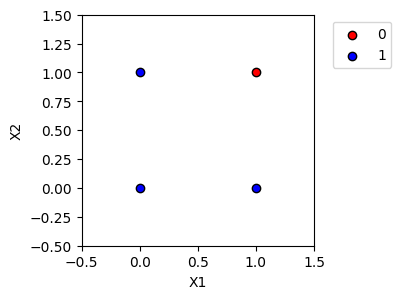

In [13]:
plot_points(NAND_plot_data[:,0:2],NAND_plot_data[:,2])

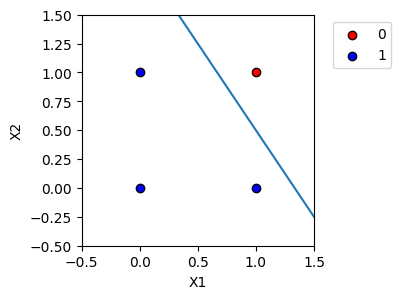

In [14]:
plot_decision_boundary(NAND_plot_data[:,0:2],NAND_plot_data[:,2],w_NAND.reshape((3,-1)))

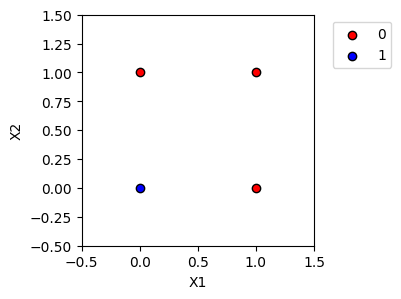

In [15]:
plot_points(NOR_plot_data[:,0:2],NOR_plot_data[:,2])

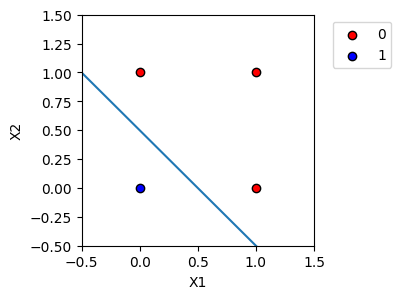

In [16]:
plot_decision_boundary(NOR_plot_data[:,0:2],NOR_plot_data[:,2],w_NOR.reshape((3,-1)))

### TASK 6

In [17]:
w_XNOR = np.array([0,0,0])
counter = 0
while counter < 3001:
    possible,v_fail=check(algo_XNOR_data,w_XNOR)
    if possible:
        break
    w_XNOR=w_XNOR+v_fail
    counter+=1


counter = 0
w_XOR = np.array([0,0,0])
while counter < 3001:
    possible,v_fail=check(algo_XOR_data,w_XOR)
    if possible:
        break
    w_XOR=w_XOR+v_fail
    counter+=1

haha


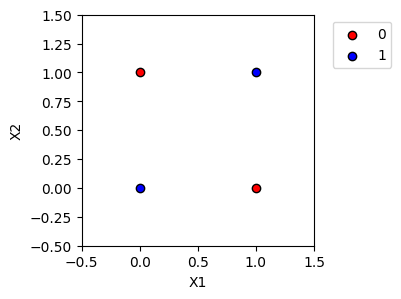

In [20]:
plot_points(XNOR_plot_data[:,0:2],XNOR_plot_data[:,2])

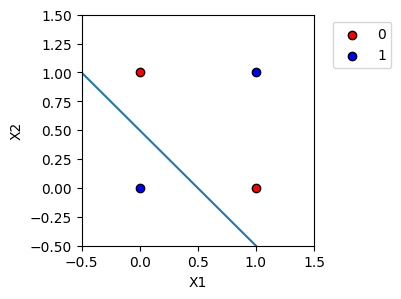

In [21]:
plot_decision_boundary(XNOR_plot_data[:,0:2],XNOR_plot_data[:,2],w_XNOR.reshape((3,-1)))

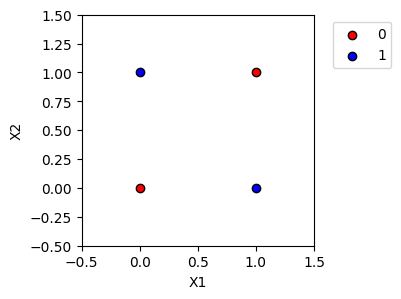

In [23]:
plot_points(XOR_plot_data[:,0:2],XOR_plot_data[:,2])

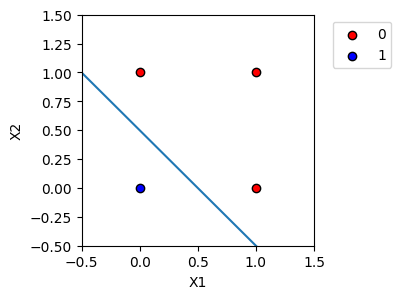

In [62]:
plot_decision_boundary(NOR_plot_data[:,0:2],NOR_plot_data[:,2],w_NOR.reshape((3,-1)))

In [73]:
X_xor = np.array([
    [-1,0,0],
    [-1,0,1],
    [-1,1,0],
    [-1,1,1]
])
Y_xor = np.array([
    [0],
    [1],
    [1],
    [0]
])
X_xnor = np.array([
    [-1,0,0],
    [-1,0,1],
    [-1,1,0],
    [-1,1,1]
])
Y_xnor = np.array([
    [1],
    [0],
    [0],
    [1]
])
X_nand = np.array([
    [-1,0,0],
    [-1,0,1],
    [-1,1,0],
    [-1,1,1]
])
Y_nand = np.array([
    [1],
    [1],
    [1],
    [0]
])
X_nor = np.array([
    [-1,0,0],
    [-1,0,1],
    [-1,1,0],
    [-1,1,1]
])
Y_nor = np.array([
    [1],
    [0],
    [0],
    [0]
])

In [49]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [26]:
def sigmoid_derivative(x):
    return x*(1-x) 

In [98]:
def binary_cross_entropy(y, y_pred):
    return -np.sum(y*np.log(y_pred)+(1-y)*np.log(1-y_pred))

In [99]:
def mse_loss(y, y_pred):
    return np.sum((y-y_pred)**2)

In [108]:
def train_perceptron(X, Y):
    w = np.array([1.0, 2.0, 3.0]) 
    learning_rate = 0.1
    losses = []
    
    for i in range(10000):
        out1 = np.dot(X, w)
        output = sigmoid(out1)
        output = output.reshape(-1, 1)
        
        loss = binary_cross_entropy(Y, output)
        losses.append(loss)
        
        d_loss = output - Y
    
        w -= learning_rate * np.dot(X.T, d_loss).flatten() 
        
    predictions = sigmoid(np.dot(X, w))
    predictions = [1 if p > 0.9 else 0 for p in predictions]

    return w, predictions

In [109]:
w_xor, predictions_xor = train_perceptron(X_xor,Y_xor)
predictions_xor
                  

[0, 0, 0, 0]

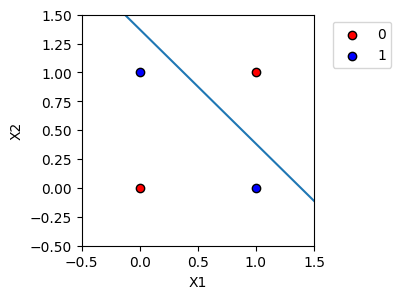

In [110]:
plot_decision_boundary(X_xor[:,1:],Y_xor,w_xor)

[0, 0, 0, 0]


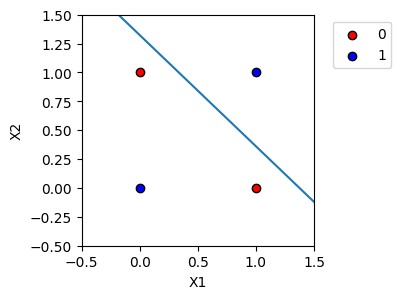

In [111]:
w_xnor, predictions_xnor = train_perceptron(X_xnor,Y_xnor)
print(predictions_xnor)
plot_decision_boundary(X_xnor[:,1:],Y_xnor,w_xnor)

[1, 0, 0, 0]


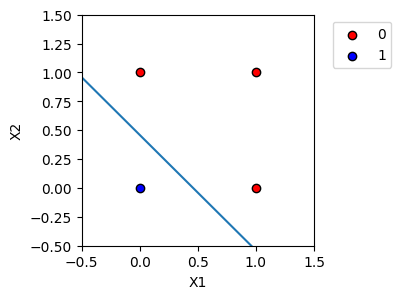

In [112]:
w_nor, predictions_nor = train_perceptron(X_nor,Y_nor)
print(predictions_nor)
plot_decision_boundary(X_nor[:,1:],Y_nor,w_nor)

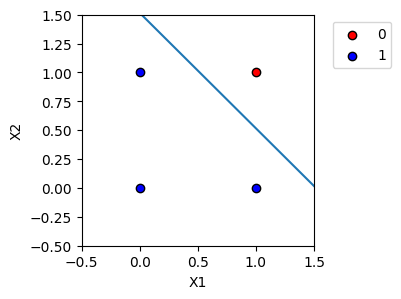

In [113]:
w_nand, predictions_nand = train_perceptron(X_nand,Y_nand)
predictions_nand
plot_decision_boundary(X_nand[:,1:],Y_nand,w_nand.reshape((3,-1)))

In [107]:
w_nand

array([-3.54827372,  1.68648474,  2.4629667 ])

In [114]:
def train_perceptron_mse(X, Y):
    w = np.array([1.0, 2.0, 3.0]) 
    learning_rate = 0.1
    losses = []
    
    for i in range(10000):
        out1 = np.dot(X, w)
        output = sigmoid(out1)
        output = output.reshape(-1, 1)
        
        loss = mse_loss(Y, output)
        losses.append(loss)
        
        d_loss =2*(output - Y)
    
        w -= learning_rate * np.dot(X.T, d_loss).flatten() 
        
    predictions = sigmoid(np.dot(X, w))
    predictions = [1 if p > 0.9 else 0 for p in predictions]

    return w, predictions

[0, 0, 0, 0]


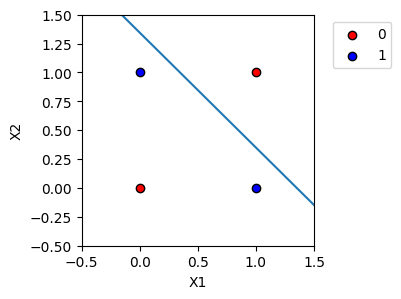

In [115]:
w_xor, predictions_xor = train_perceptron_mse(X_xor,Y_xor)
print(predictions_xor)
plot_decision_boundary(X_xor[:,1:],Y_xor,w_xor)

[0, 0, 0, 0]


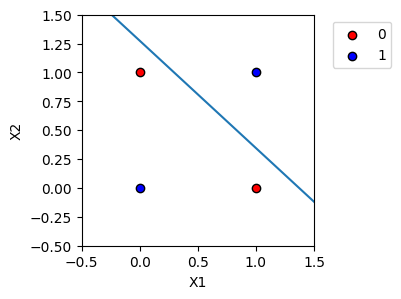

In [116]:
w_xnor, predictions_xnor = train_perceptron_mse(X_xnor,Y_xnor)
print(predictions_xnor)
plot_decision_boundary(X_xnor[:,1:],Y_xnor,w_xnor)

[1, 1, 1, 0]


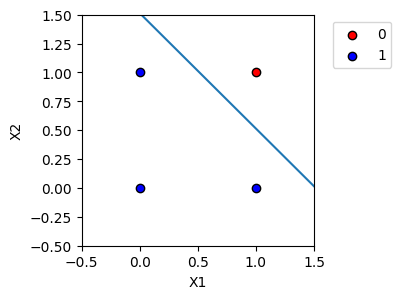

In [117]:
w_nand, predictions_nand = train_perceptron_mse(X_nand,Y_nand)
print(predictions_nand)
plot_decision_boundary(X_nand[:,1:],Y_nand,w_nand)

[1, 0, 0, 0]


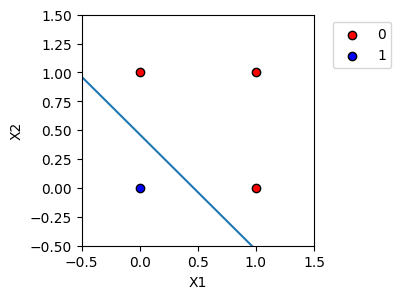

In [118]:
w_nor, predictions_nor = train_perceptron_mse(X_nor,Y_nor)
print(predictions_nor)
plot_decision_boundary(X_nor[:,1:],Y_nor,w_nor)